In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

from athena_client import query

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

OUTPUT = os.path.expanduser('~/sus-saude-mental-analytics/output')
os.makedirs(OUTPUT, exist_ok=True)

print("✅ Imports OK")

✅ Imports OK


In [4]:
print("=" * 60)
print("INVENTÁRIO DE FONTES DE DADOS")
print("=" * 60)

fontes = {
    'SIH — internações psiquiátricas': """
        SELECT ano, COUNT(*) as total
        FROM sus_pipeline.sih_internacoes_psiquiatria
        GROUP BY ano ORDER BY ano
    """,
    'SIM — suicídios': """
        SELECT ano, COUNT(*) as total
        FROM sus_pipeline.sim_suicidios
        GROUP BY ano ORDER BY ano
    """,
    'RAAS — atendimentos CAPS': """
        SELECT ano, COUNT(*) as total
        FROM sus_pipeline.raas_atendimentos
        GROUP BY ano ORDER BY ano
    """,
    'SINAN — violência': """
        SELECT ano, COUNT(*) as total
        FROM sus_pipeline.sinan_violencia_silver
        WHERE ano IS NOT NULL
        GROUP BY ano ORDER BY ano
    """,
    'IBGE — população estimada': """
        SELECT ano, COUNT(DISTINCT cod_municipio) as municipios
        FROM sus_pipeline.ibge_populacao
        GROUP BY ano ORDER BY ano
    """,
    'PNADC — microdados SP': """
        SELECT ano, COUNT(*) as total
        FROM sus_pipeline.pnadc_sp_silver
        GROUP BY ano ORDER BY ano
    """,
}

resumo = []
for nome, sql in fontes.items():
    try:
        df = query(sql)
        anos = f"{df['ano'].min()} — {df['ano'].max()}"
        total = df['total'].sum() if 'total' in df.columns else df['municipios'].sum()
        resumo.append({'fonte': nome, 'período': anos, 'total': f"{total:,}"})
        print(f"✅ {nome}: {anos} | {total:,} registros")
    except Exception as e:
        print(f"❌ {nome}: {e}")

print("\n✅ Inventário concluído!")

INVENTÁRIO DE FONTES DE DADOS
✅ SIH — internações psiquiátricas: 2015 — 2026 | 1,085,366 registros
✅ SIM — suicídios: 2018 — 2024 | 17,955 registros
✅ RAAS — atendimentos CAPS: 2017 — 2025 | 33,718,394 registros
✅ SINAN — violência: 2015 — 2025 | 1,181,083 registros
✅ IBGE — população estimada: 2015 — 2025 | 7,095 registros
✅ PNADC — microdados SP: 2015 — 2023 | 358,220 registros

✅ Inventário concluído!


In [5]:
print("Carregando dados agregados...")

# internações por ano
df_ano = query("""
    SELECT * FROM sus_pipeline.internacoes_por_ano
    WHERE ano NOT IN ('2026')
    ORDER BY ano
""")
df_ano['ano'] = df_ano['ano'].astype(int)

# suicídios por ano
df_suicidios = query("""
    SELECT ano,
           SUM(total_suicidios) AS total_suicidios,
           SUM(total_masculino) AS masculino,
           SUM(total_feminino)  AS feminino,
           SUM(por_enforcamento) AS enforcamento,
           SUM(por_arma_fogo)   AS arma_fogo,
           SUM(por_envenenamento) AS envenenamento,
           SUM(por_salto)       AS salto
    FROM sus_pipeline.suicidios_por_ano
    GROUP BY ano ORDER BY ano
""")
df_suicidios['ano'] = df_suicidios['ano'].astype(int)

# atendimentos CAPS por ano
df_atend = query("""
    SELECT ano,
           SUM(total_atendimentos)  AS total_atendimentos,
           SUM(total_masculino)     AS masculino,
           SUM(total_feminino)      AS feminino,
           SUM(atend_uso_drogas)    AS uso_drogas,
           SUM(total_situacao_rua)  AS situacao_rua
    FROM sus_pipeline.atendimentos_por_ano
    WHERE ano NOT IN ('2017')
    GROUP BY ano ORDER BY ano
""")
df_atend['ano'] = df_atend['ano'].astype(int)

# violência por ano
df_viol = query("""
    SELECT * FROM sus_pipeline.violencia_por_ano
    WHERE ano NOT IN ('2026')
    ORDER BY ano
""")
df_viol['ano'] = df_viol['ano'].astype(int)

# municípios
df_mun = query("""
    SELECT * FROM sus_pipeline.saude_mental_municipios
    WHERE populacao_total > 0
    AND municipio IS NOT NULL
    AND ano NOT IN ('2026')
    ORDER BY ano, total_internacoes DESC
""")

# PNADC
df_pnadc = query("""
    SELECT * FROM sus_pipeline.pnadc_sp_silver
    WHERE renda_todos_trabalhos IS NOT NULL
    ORDER BY ano
""")
df_pnadc['ano'] = df_pnadc['ano'].astype(int)

print(f"✅ internacoes_por_ano:    {len(df_ano)} anos ({df_ano['ano'].min()}–{df_ano['ano'].max()})")
print(f"✅ suicidios_por_ano:      {len(df_suicidios)} anos ({df_suicidios['ano'].min()}–{df_suicidios['ano'].max()})")
print(f"✅ atendimentos_por_ano:   {len(df_atend)} anos ({df_atend['ano'].min()}–{df_atend['ano'].max()})")
print(f"✅ violencia_por_ano:      {len(df_viol)} anos ({df_viol['ano'].min()}–{df_viol['ano'].max()})")
print(f"✅ saude_mental_municipios:{len(df_mun)} linhas")
print(f"✅ pnadc_sp_silver:        {len(df_pnadc):,} registros")

Carregando dados agregados...
✅ internacoes_por_ano:    11 anos (2015–2025)
✅ suicidios_por_ano:      7 anos (2018–2024)
✅ atendimentos_por_ano:   8 anos (2018–2025)
✅ violencia_por_ano:      11 anos (2015–2025)
✅ saude_mental_municipios:2839 linhas
✅ pnadc_sp_silver:        167,358 registros


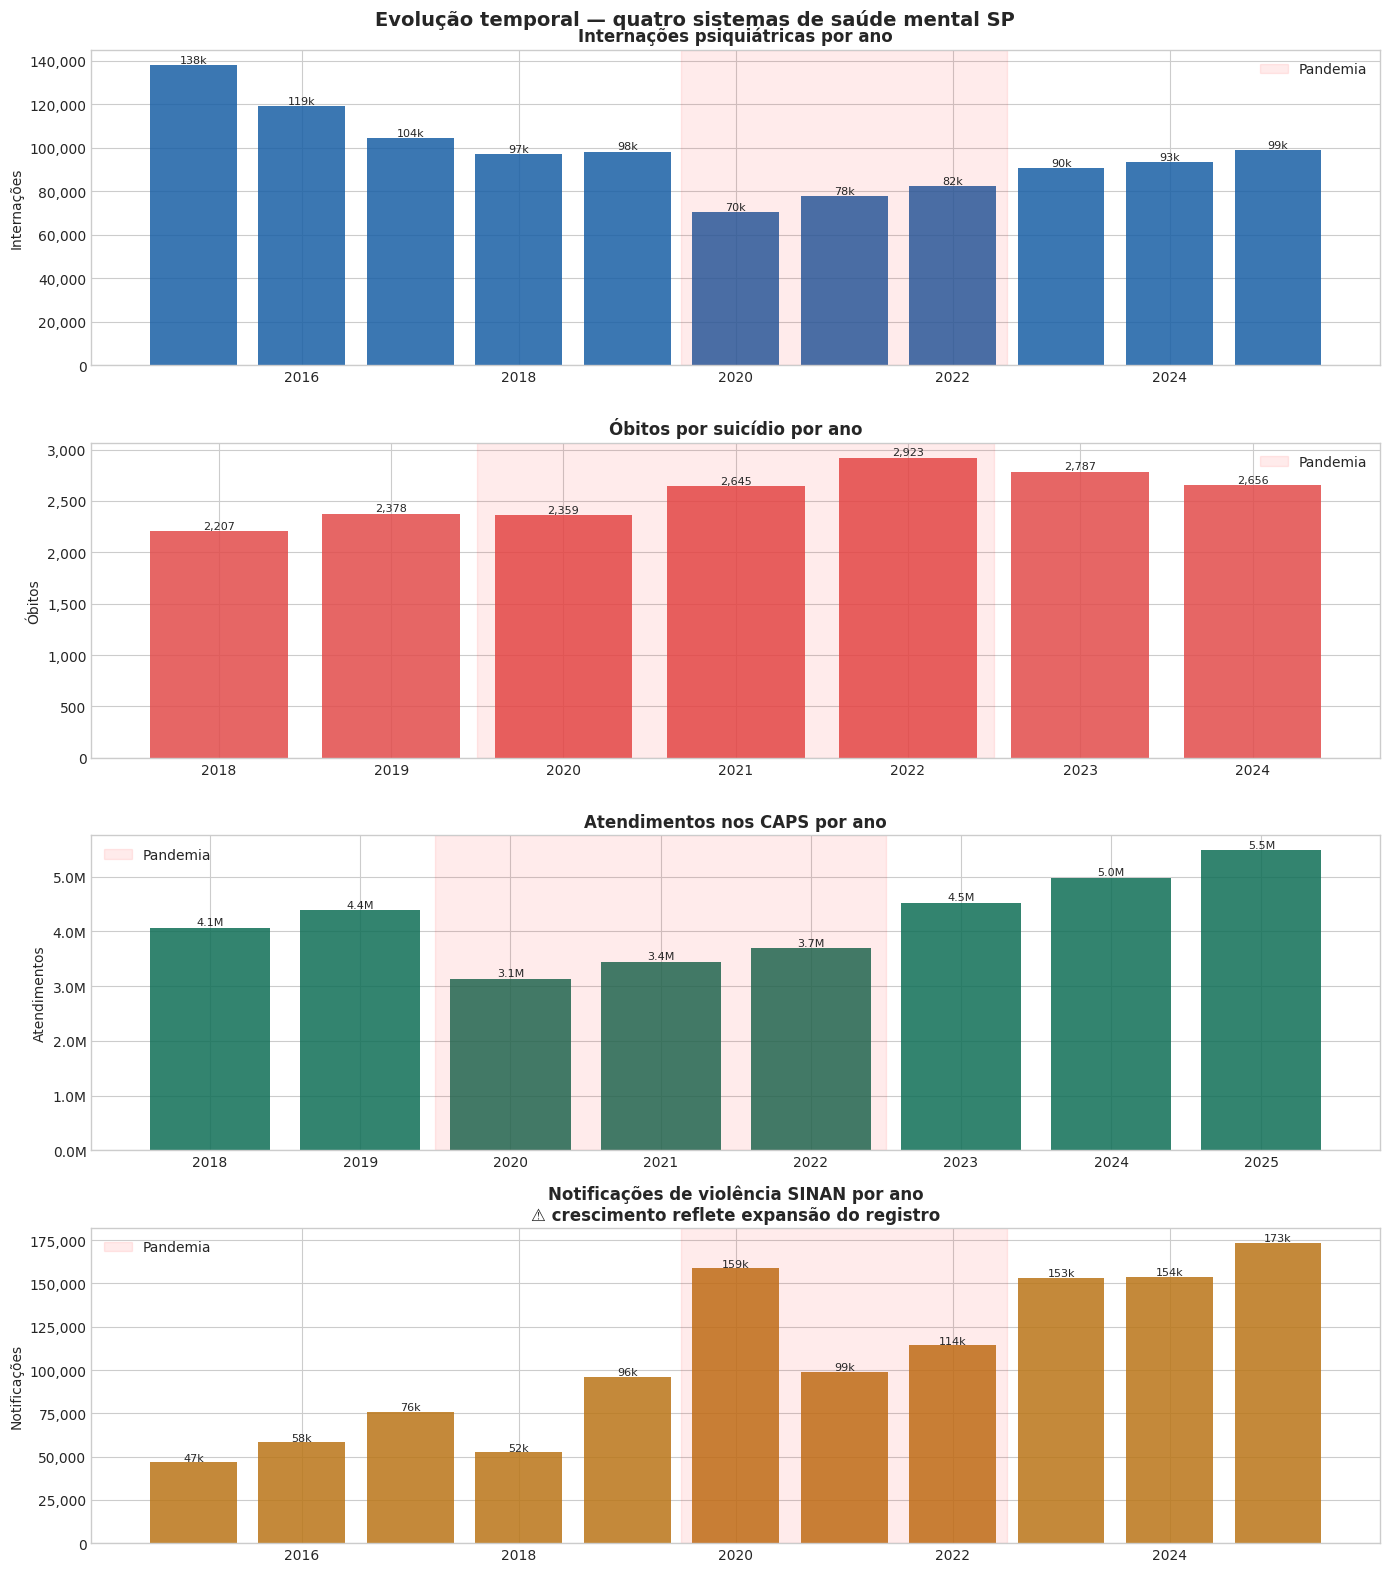

✅ Gráfico salvo!


In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

# internações
ax = axes[0]
ax.bar(df_ano['ano'], df_ano['total_internacoes'].astype(float),
       color='#185FA5', alpha=0.85)
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
for bar, v in zip(ax.patches, df_ano['total_internacoes'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1000:.0f}k', ha='center', fontsize=8)
ax.set_title('Internações psiquiátricas por ano', fontweight='bold')
ax.set_ylabel('Internações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.set_ylim(bottom=0)

# suicídios
ax = axes[1]
ax.bar(df_suicidios['ano'], df_suicidios['total_suicidios'].astype(float),
       color='#E24B4A', alpha=0.85)
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
for bar, v in zip(ax.patches, df_suicidios['total_suicidios'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{v:,.0f}', ha='center', fontsize=8)
ax.set_title('Óbitos por suicídio por ano', fontweight='bold')
ax.set_ylabel('Óbitos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.set_ylim(bottom=0)

# atendimentos CAPS
ax = axes[2]
ax.bar(df_atend['ano'], df_atend['total_atendimentos'].astype(float),
       color='#0F6E56', alpha=0.85)
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
for bar, v in zip(ax.patches, df_atend['total_atendimentos'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'{v/1e6:.1f}M', ha='center', fontsize=8)
ax.set_title('Atendimentos nos CAPS por ano', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
ax.set_ylim(bottom=0)

# violência
ax = axes[3]
ax.bar(df_viol['ano'], df_viol['total_notificacoes'].astype(float),
       color='#BA7517', alpha=0.85)
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
for bar, v in zip(ax.patches, df_viol['total_notificacoes'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1000:.0f}k', ha='center', fontsize=8)
ax.set_title('Notificações de violência SINAN por ano\n⚠️ crescimento reflete expansão do registro',
             fontweight='bold')
ax.set_ylabel('Notificações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.set_ylim(bottom=0)

plt.suptitle('Evolução temporal — quatro sistemas de saúde mental SP',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/01_evolucao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

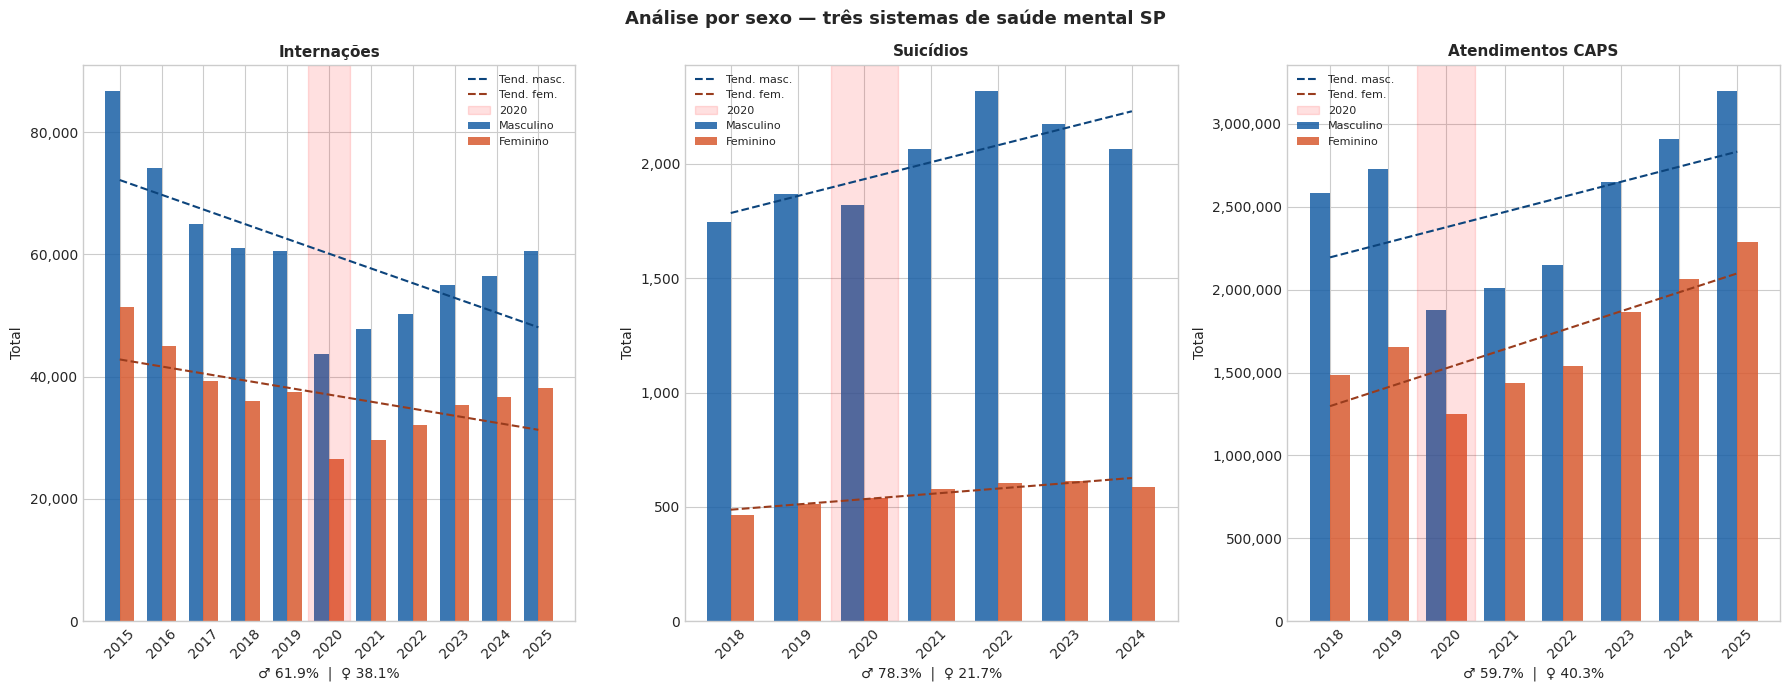

✅ Gráfico salvo!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

datasets = [
    (df_ano, 'total_masculino', 'total_feminino', 'Internações', 'ano'),
    (df_suicidios, 'masculino', 'feminino', 'Suicídios', 'ano'),
    (df_atend, 'masculino', 'feminino', 'Atendimentos CAPS', 'ano'),
]

for ax, (df, col_m, col_f, titulo, col_ano) in zip(axes, datasets):
    anos = df[col_ano].values
    x = np.arange(len(anos))
    largura = 0.35

    ax.bar(x - largura/2, df[col_m].astype(float), largura,
           label='Masculino', color='#185FA5', alpha=0.85)
    ax.bar(x + largura/2, df[col_f].astype(float), largura,
           label='Feminino', color='#D85A30', alpha=0.85)

    # linha de tendência
    z_m = np.polyfit(x, df[col_m].astype(float), 1)
    z_f = np.polyfit(x, df[col_f].astype(float), 1)
    ax.plot(x, np.poly1d(z_m)(x), '--', color='#0C447C', linewidth=1.5, label='Tend. masc.')
    ax.plot(x, np.poly1d(z_f)(x), '--', color='#993C1D', linewidth=1.5, label='Tend. fem.')

    # destaca 2020
    if 2020 in list(anos):
        idx = list(anos).index(2020)
        ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.12, color='red', label='2020')

    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Total')
    ax.set_xticks(x)
    ax.set_xticklabels(anos, rotation=45)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    total_m = df[col_m].astype(float).sum()
    total_f = df[col_f].astype(float).sum()
    pct_m = total_m / (total_m + total_f) * 100
    ax.set_xlabel(f'♂ {pct_m:.1f}%  |  ♀ {100-pct_m:.1f}%', fontsize=10)

plt.suptitle('Análise por sexo — três sistemas de saúde mental SP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/02_analise_sexo.png', dpi=150, bbox_inches='tight')
plt.show()

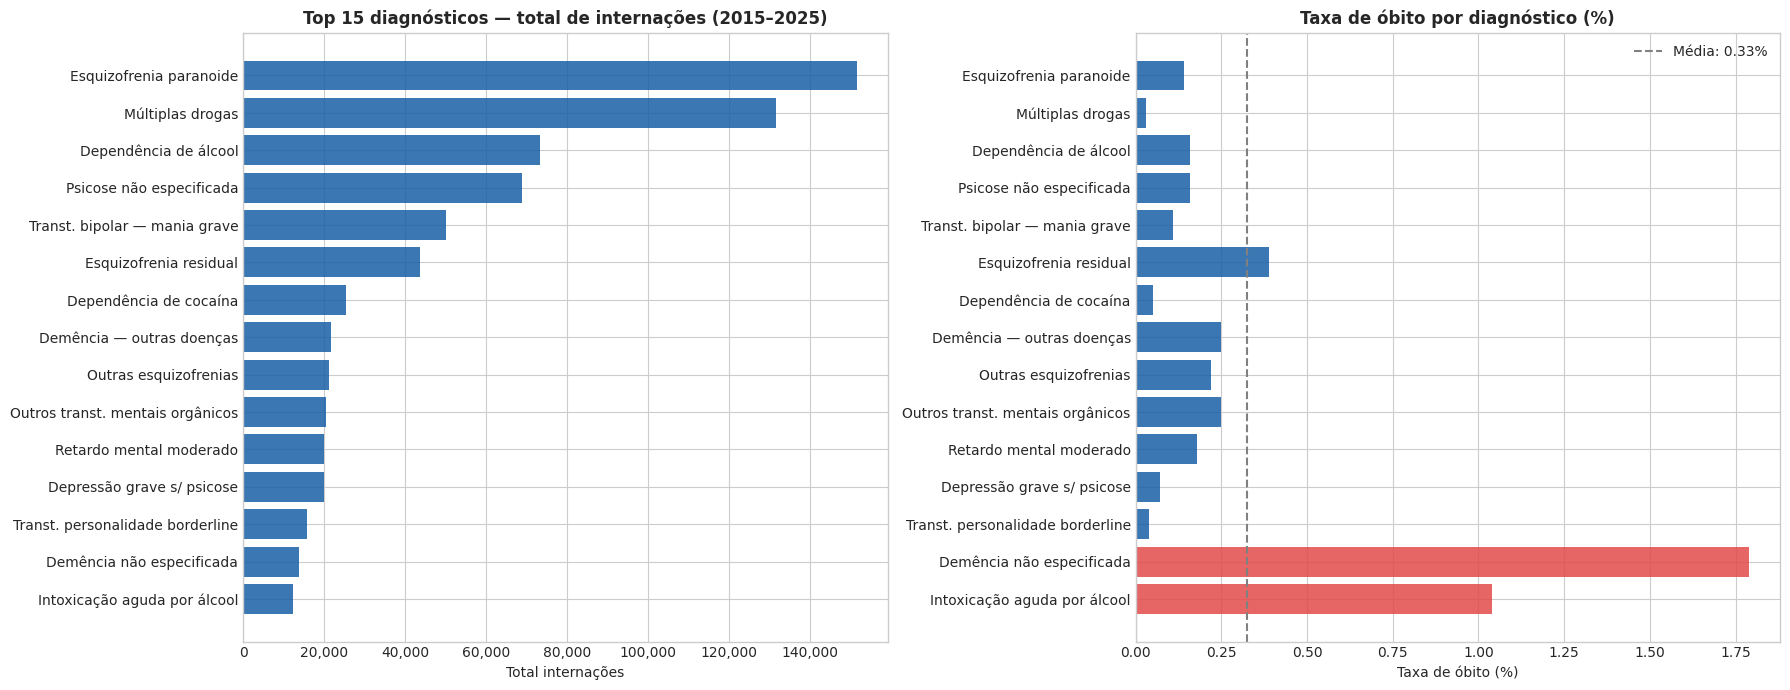

In [9]:
df_cid = query("""
    SELECT cid_principal,
           SUM(total_internacoes) AS total_internacoes,
           SUM(total_obitos)      AS total_obitos,
           ROUND(SUM(total_obitos) * 100.0 / SUM(total_internacoes), 2) AS taxa_obito
    FROM sus_pipeline.internacoes_por_cid
    GROUP BY cid_principal
    ORDER BY total_internacoes DESC
""")

df_cid['cid_principal'] = df_cid['cid_principal'].str.strip()

cid_map = {
    'F192': 'Múltiplas drogas',
    'F200': 'Esquizofrenia paranoide',
    'F102': 'Dependência de álcool',
    'F29':  'Psicose não especificada',
    'F312': 'Transt. bipolar — mania grave',
    'F142': 'Dependência de cocaína',
    'F205': 'Esquizofrenia residual',
    'F322': 'Depressão grave s/ psicose',
    'F028': 'Demência — outras doenças',
    'F208': 'Outras esquizofrenias',
    'F603': 'Transt. personalidade borderline',
    'F068': 'Outros transt. mentais orgânicos',
    'F323': 'Depressão grave c/ psicose',
    'F03':  'Demência não especificada',
    'F721': 'Retardo mental moderado',
    'F100': 'Intoxicação aguda por álcool',
}
df_cid['descricao'] = df_cid['cid_principal'].map(cid_map).fillna(df_cid['cid_principal'])
top15 = df_cid.nlargest(15, 'total_internacoes')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top15['descricao'], top15['total_internacoes'].astype(float),
             color='#185FA5', alpha=0.85)
axes[0].set_title('Top 15 diagnósticos — total de internações (2015–2025)',
                  fontweight='bold')
axes[0].set_xlabel('Total internações')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].invert_yaxis()

cores = ['#E24B4A' if x > 0.5 else '#185FA5' for x in top15['taxa_obito'].astype(float)]
axes[1].barh(top15['descricao'], top15['taxa_obito'].astype(float),
             color=cores, alpha=0.85)
axes[1].set_title('Taxa de óbito por diagnóstico (%)', fontweight='bold')
axes[1].set_xlabel('Taxa de óbito (%)')
axes[1].invert_yaxis()
axes[1].axvline(x=top15['taxa_obito'].astype(float).mean(), color='gray',
                linestyle='--',
                label=f'Média: {top15["taxa_obito"].astype(float).mean():.2f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT}/03_analise_cid.png', dpi=150, bbox_inches='tight')
plt.show()

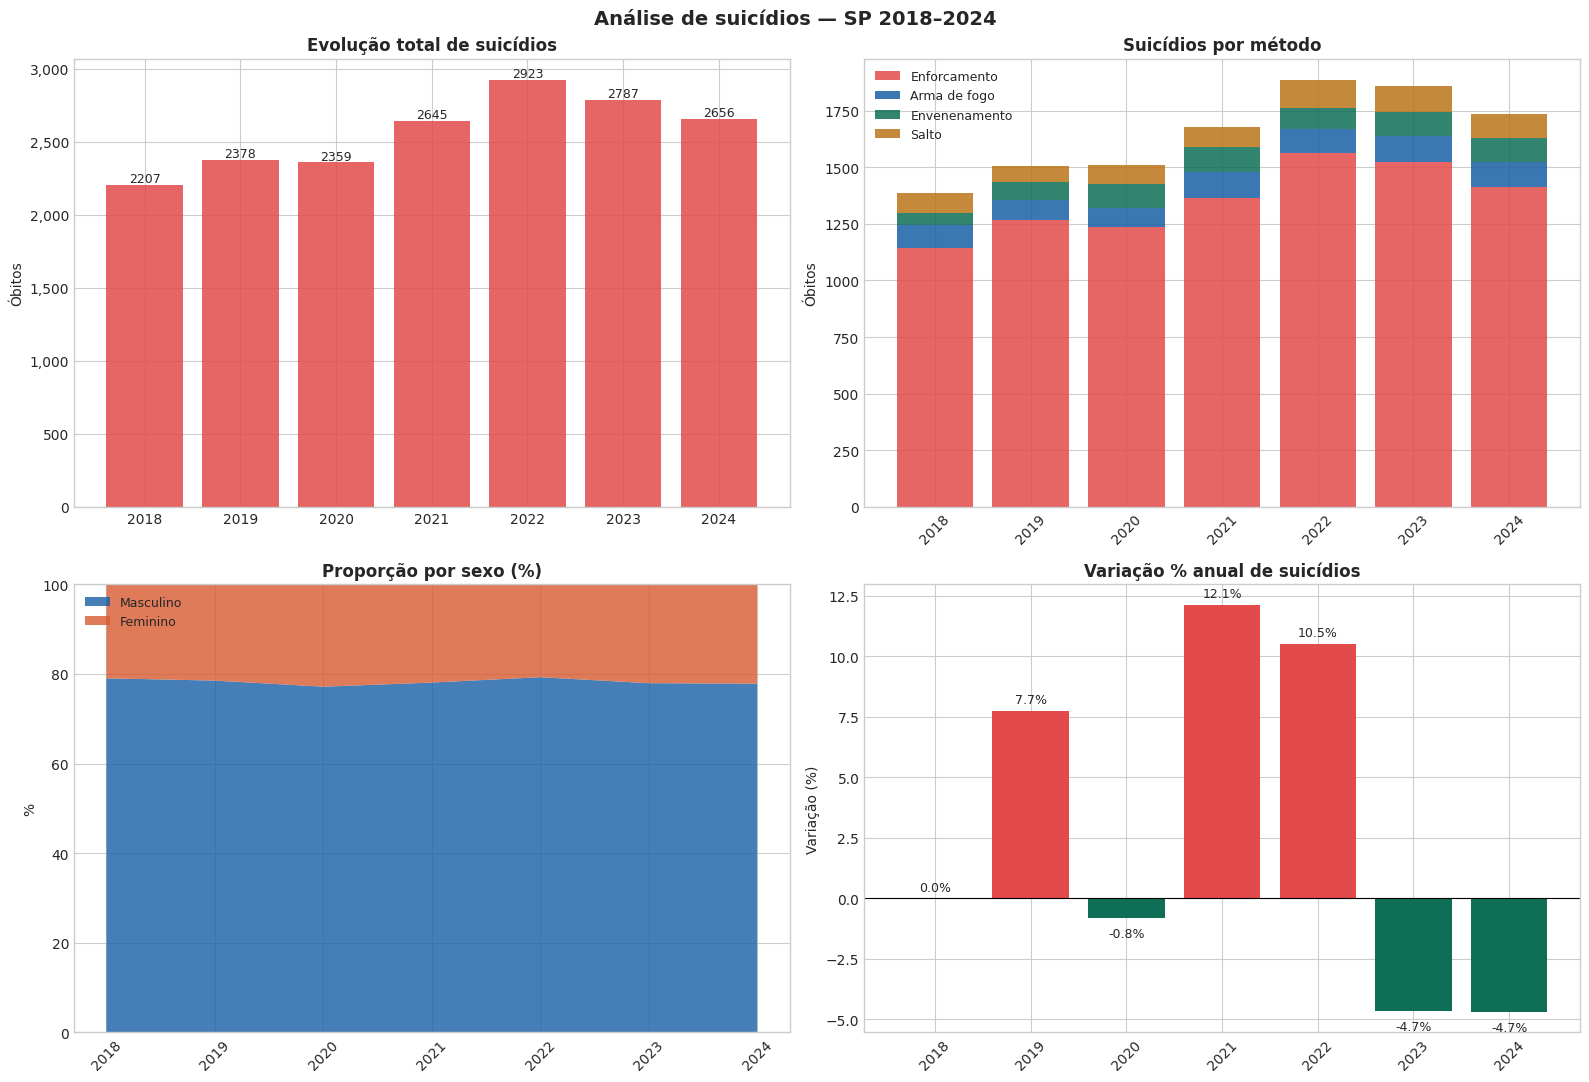

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# evolução total
ax = axes[0, 0]
bars = ax.bar(df_suicidios['ano'], df_suicidios['total_suicidios'].astype(float),
              color='#E24B4A', alpha=0.85)
for bar, v in zip(bars, df_suicidios['total_suicidios'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(v)), ha='center', fontsize=9)
ax.set_title('Evolução total de suicídios', fontweight='bold')
ax.set_ylabel('Óbitos')
ax.set_xticks(df_suicidios['ano'])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# por método
ax = axes[0, 1]
metodos = ['enforcamento', 'arma_fogo', 'envenenamento', 'salto']
labels_m = ['Enforcamento', 'Arma de fogo', 'Envenenamento', 'Salto']
cores_m = ['#E24B4A', '#185FA5', '#0F6E56', '#BA7517']
bottom = np.zeros(len(df_suicidios))
for metodo, label, cor in zip(metodos, labels_m, cores_m):
    ax.bar(df_suicidios['ano'], df_suicidios[metodo].astype(float),
           bottom=bottom, label=label, color=cor, alpha=0.85)
    bottom += df_suicidios[metodo].astype(float).values
ax.set_title('Suicídios por método', fontweight='bold')
ax.set_ylabel('Óbitos')
ax.legend(fontsize=9)
ax.set_xticks(df_suicidios['ano'])
ax.tick_params(axis='x', rotation=45)

# proporção por sexo
ax = axes[1, 0]
pct_m = df_suicidios['masculino'].astype(float) / df_suicidios['total_suicidios'].astype(float) * 100
pct_f = df_suicidios['feminino'].astype(float) / df_suicidios['total_suicidios'].astype(float) * 100
ax.stackplot(df_suicidios['ano'], pct_m, pct_f,
             labels=['Masculino', 'Feminino'],
             colors=['#185FA5', '#D85A30'], alpha=0.8)
ax.set_title('Proporção por sexo (%)', fontweight='bold')
ax.set_ylabel('%')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(df_suicidios['ano'])
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 100)

# variação % ano a ano
ax = axes[1, 1]
variacao = df_suicidios['total_suicidios'].astype(float).pct_change() * 100
cores_var = ['#E24B4A' if v > 0 else '#0F6E56' for v in variacao.fillna(0)]
ax.bar(df_suicidios['ano'], variacao.fillna(0), color=cores_var)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Variação % anual de suicídios', fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.set_xticks(df_suicidios['ano'])
ax.tick_params(axis='x', rotation=45)
for ano, v in zip(df_suicidios['ano'], variacao.fillna(0)):
    ax.text(ano, v + (0.3 if v >= 0 else -0.8), f'{v:.1f}%',
            ha='center', fontsize=9)

plt.suptitle('Análise de suicídios — SP 2018–2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/04_suicidios.png', dpi=150, bbox_inches='tight')
plt.show()

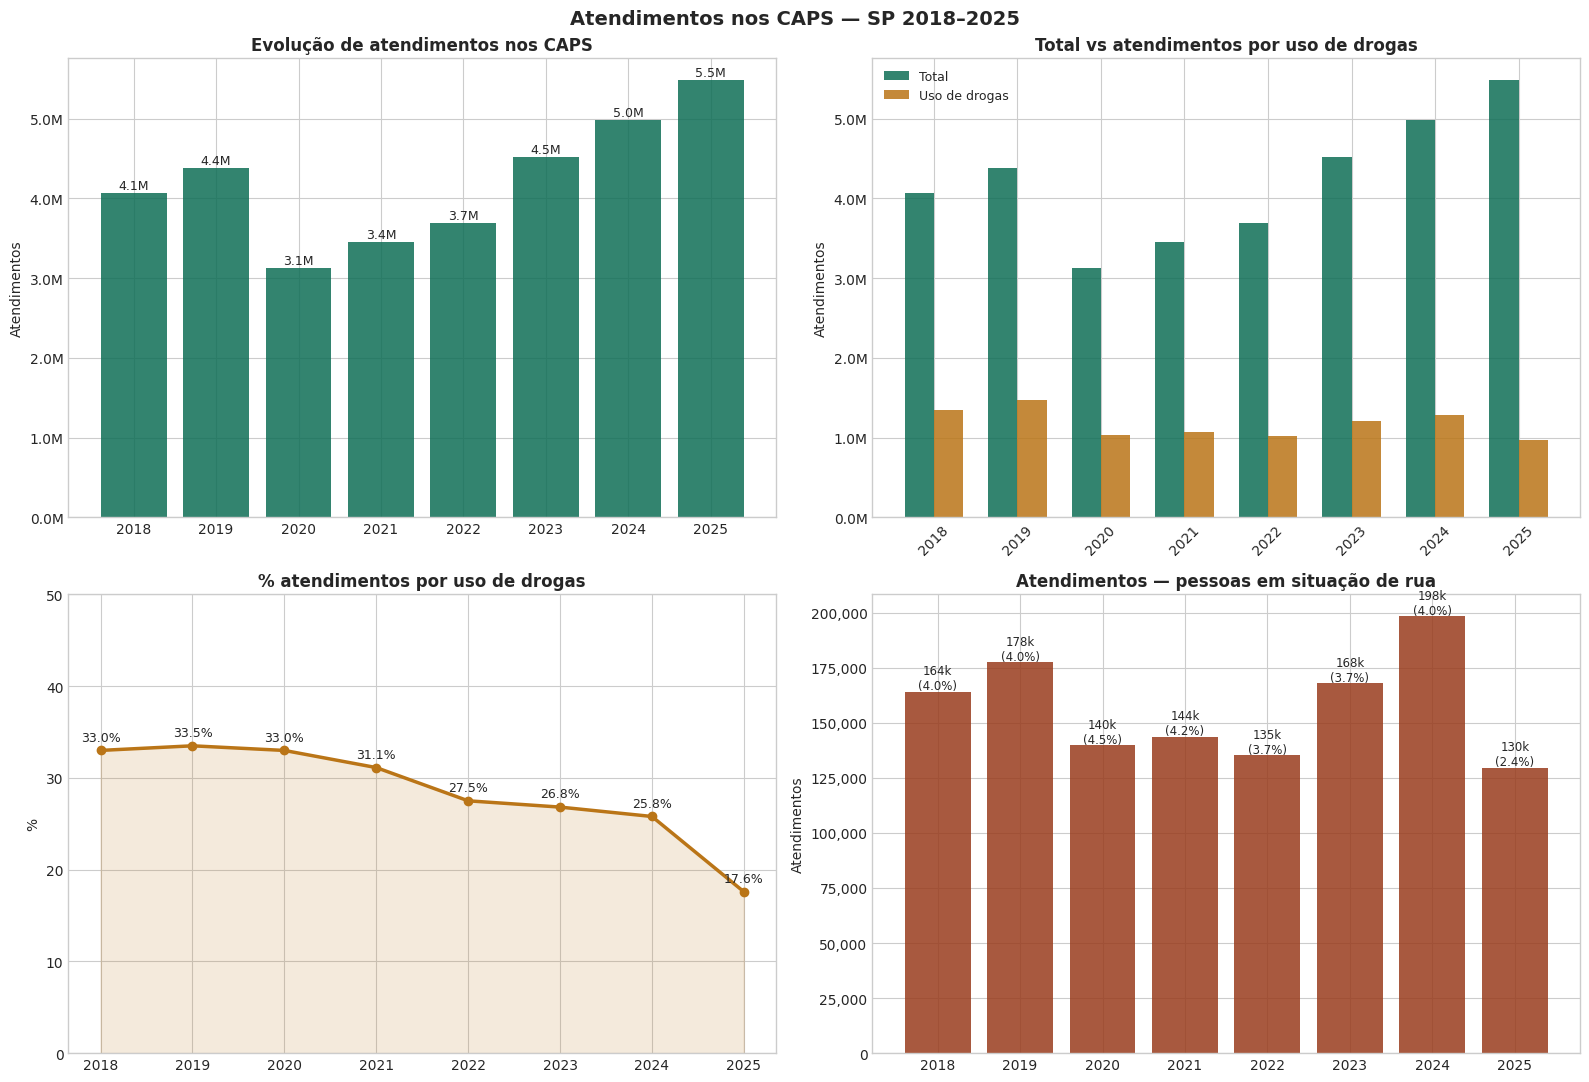

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# evolução total
ax = axes[0, 0]
bars = ax.bar(df_atend['ano'], df_atend['total_atendimentos'].astype(float),
              color='#0F6E56', alpha=0.85)
for bar, v in zip(bars, df_atend['total_atendimentos'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'{v/1e6:.1f}M', ha='center', fontsize=9)
ax.set_title('Evolução de atendimentos nos CAPS', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(df_atend['ano'])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# uso de drogas vs total
ax = axes[0, 1]
pct_drogas = df_atend['uso_drogas'].astype(float) / df_atend['total_atendimentos'].astype(float) * 100
x = np.arange(len(df_atend))
largura = 0.35
ax.bar(x - largura/2, df_atend['total_atendimentos'].astype(float), largura,
       label='Total', color='#0F6E56', alpha=0.85)
ax.bar(x + largura/2, df_atend['uso_drogas'].astype(float), largura,
       label='Uso de drogas', color='#BA7517', alpha=0.85)
ax.set_title('Total vs atendimentos por uso de drogas', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(x)
ax.set_xticklabels(df_atend['ano'], rotation=45)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# % uso de drogas
ax = axes[1, 0]
ax.plot(df_atend['ano'], pct_drogas, marker='o', linewidth=2.5, color='#BA7517')
ax.fill_between(df_atend['ano'], pct_drogas, alpha=0.15, color='#BA7517')
for x, y in zip(df_atend['ano'], pct_drogas):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_title('% atendimentos por uso de drogas', fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(df_atend['ano'])
ax.set_ylim(0, 50)

# situação de rua
ax = axes[1, 1]
pct_rua = df_atend['situacao_rua'].astype(float) / df_atend['total_atendimentos'].astype(float) * 100
bars = ax.bar(df_atend['ano'], df_atend['situacao_rua'].astype(float),
              color='#993C1D', alpha=0.85)
for bar, v, p in zip(bars, df_atend['situacao_rua'].astype(float), pct_rua):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1000:.0f}k\n({p:.1f}%)', ha='center', fontsize=8.5)
ax.set_title('Atendimentos — pessoas em situação de rua', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(df_atend['ano'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Atendimentos nos CAPS — SP 2018–2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/05_caps_atendimentos.png', dpi=150, bbox_inches='tight')
plt.show()

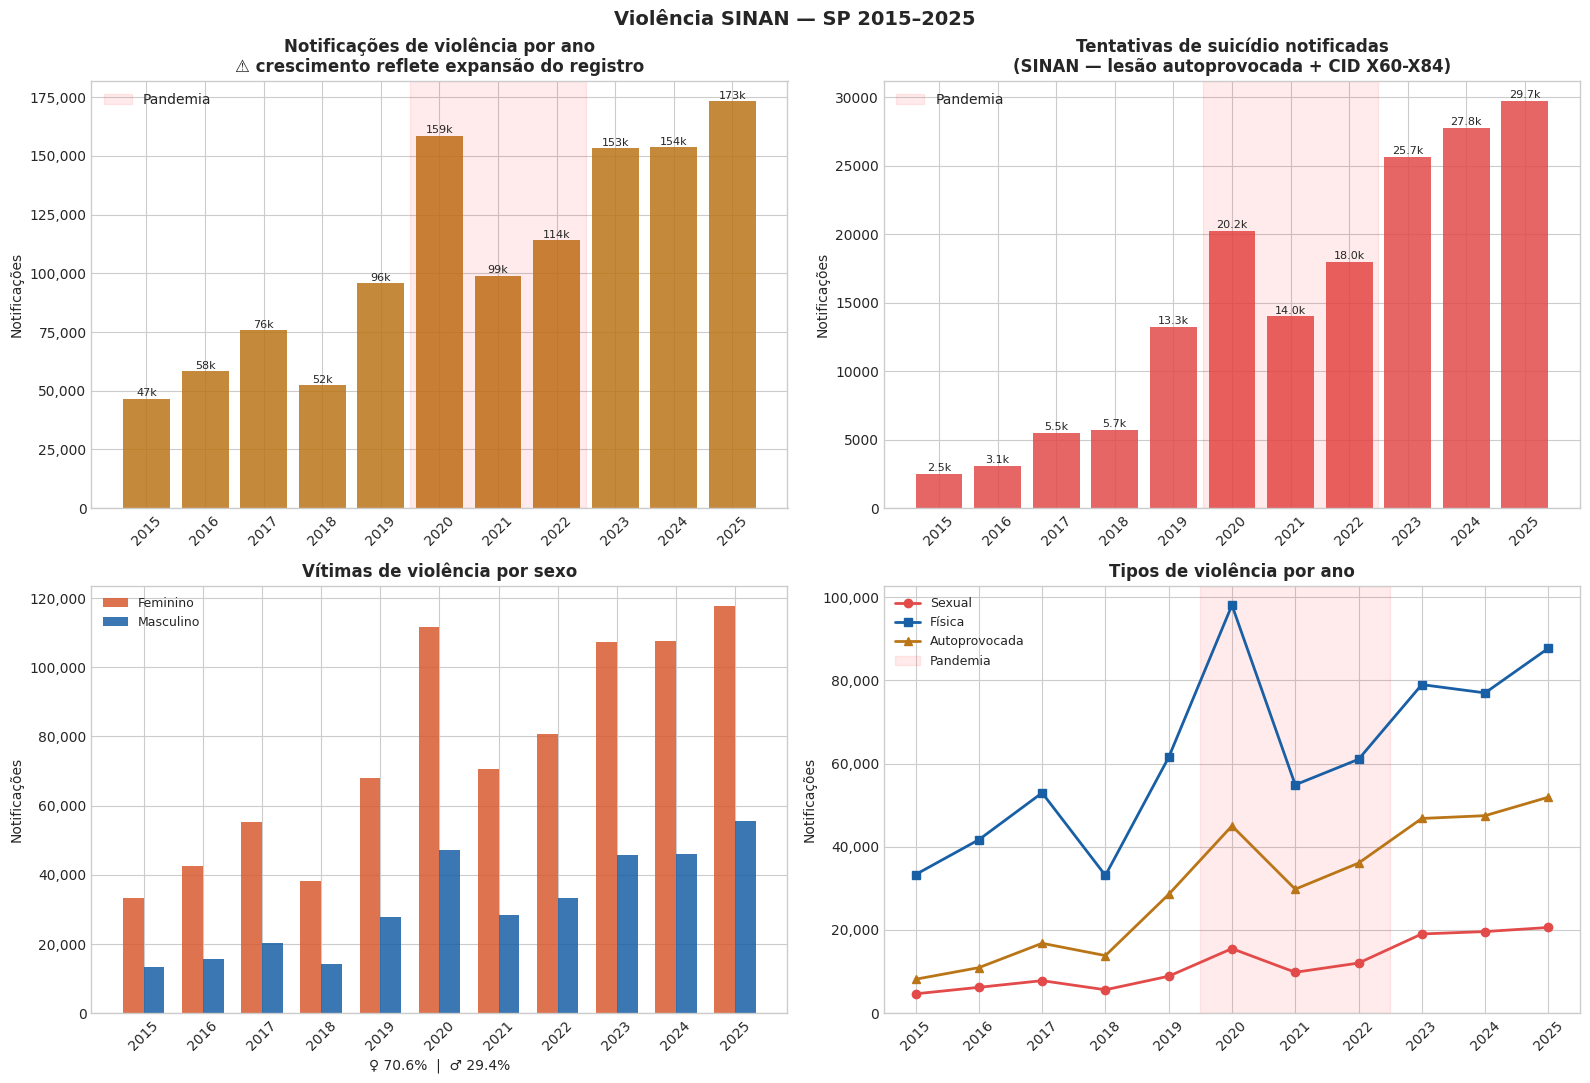

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# evolução total
ax = axes[0, 0]
bars = ax.bar(df_viol['ano'], df_viol['total_notificacoes'].astype(float),
              color='#BA7517', alpha=0.85)
for bar, v in zip(bars, df_viol['total_notificacoes'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1000:.0f}k', ha='center', fontsize=8)
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
ax.set_title('Notificações de violência por ano\n⚠️ crescimento reflete expansão do registro',
             fontweight='bold')
ax.set_ylabel('Notificações')
ax.set_xticks(df_viol['ano'])
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(bottom=0)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# tentativas de suicídio
ax = axes[0, 1]
bars = ax.bar(df_viol['ano'], df_viol['total_tentativas_suicidio'].astype(float),
              color='#E24B4A', alpha=0.85)
for bar, v in zip(bars, df_viol['total_tentativas_suicidio'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{v/1000:.1f}k', ha='center', fontsize=8)
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
ax.set_title('Tentativas de suicídio notificadas\n(SINAN — lesão autoprovocada + CID X60-X84)',
             fontweight='bold')
ax.set_ylabel('Notificações')
ax.set_xticks(df_viol['ano'])
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(bottom=0)
ax.legend()

# vítimas por sexo
ax = axes[1, 0]
x = np.arange(len(df_viol))
largura = 0.35
ax.bar(x - largura/2, df_viol['vitimas_feminino'].astype(float), largura,
       label='Feminino', color='#D85A30', alpha=0.85)
ax.bar(x + largura/2, df_viol['vitimas_masculino'].astype(float), largura,
       label='Masculino', color='#185FA5', alpha=0.85)
ax.set_title('Vítimas de violência por sexo', fontweight='bold')
ax.set_ylabel('Notificações')
ax.set_xticks(x)
ax.set_xticklabels(df_viol['ano'], rotation=45)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

total_f = df_viol['vitimas_feminino'].astype(float).sum()
total_m = df_viol['vitimas_masculino'].astype(float).sum()
pct_f = total_f / (total_f + total_m) * 100
ax.set_xlabel(f'♀ {pct_f:.1f}%  |  ♂ {100-pct_f:.1f}%', fontsize=10)

# violência sexual e física
ax = axes[1, 1]
ax.plot(df_viol['ano'], df_viol['total_violencia_sexual'].astype(float),
        marker='o', linewidth=2, color='#E24B4A', label='Sexual')
ax.plot(df_viol['ano'], df_viol['total_violencia_fisica'].astype(float),
        marker='s', linewidth=2, color='#185FA5', label='Física')
ax.plot(df_viol['ano'], df_viol['total_autoprovocada'].astype(float),
        marker='^', linewidth=2, color='#BA7517', label='Autoprovocada')
ax.axvspan(2019.5, 2022.5, alpha=0.08, color='red', label='Pandemia')
ax.set_title('Tipos de violência por ano', fontweight='bold')
ax.set_ylabel('Notificações')
ax.set_xticks(df_viol['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Violência SINAN — SP 2015–2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/06_violencia.png', dpi=150, bbox_inches='tight')
plt.show()

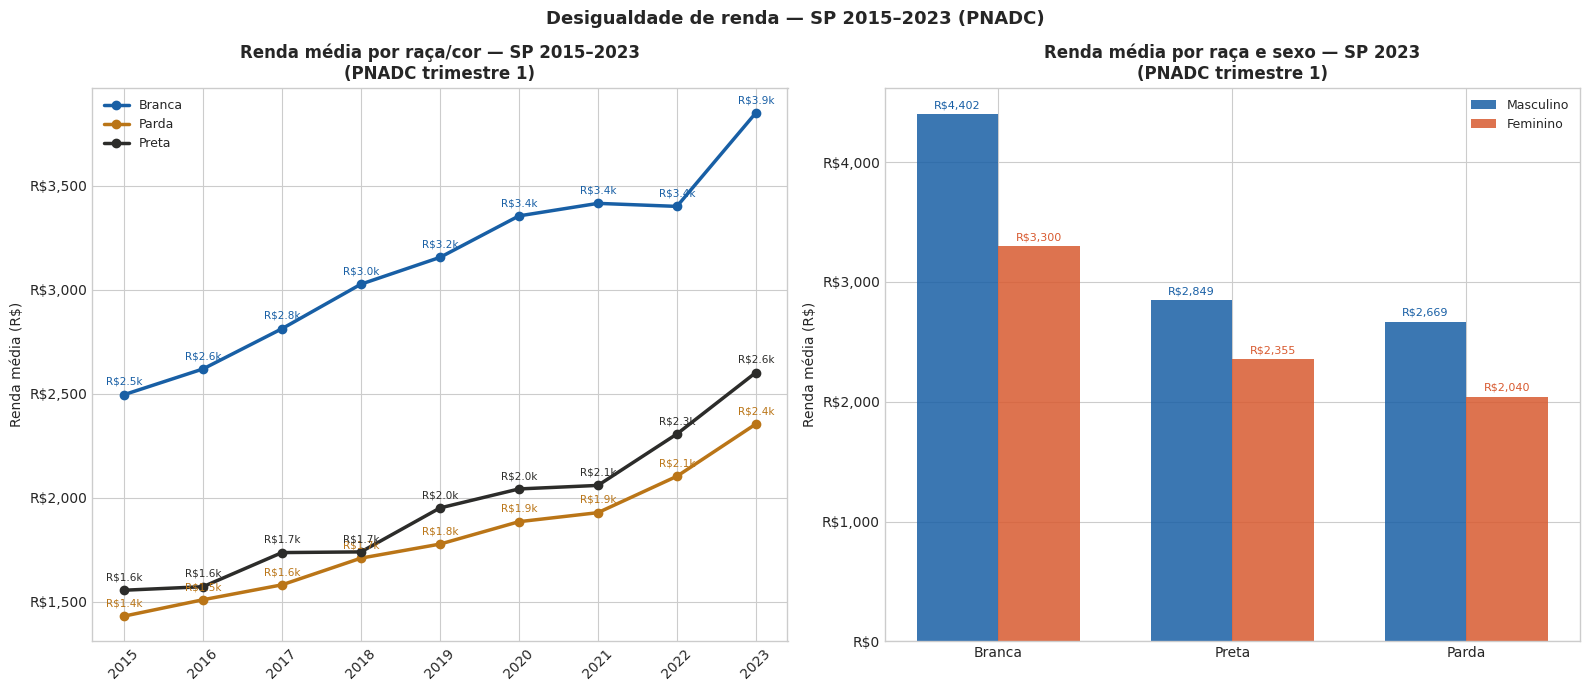

In [13]:
raca_map = {'1': 'Branca', '2': 'Preta', '3': 'Amarela',
            '4': 'Parda', '5': 'Indígena', '9': 'Ignorado'}

df_pnadc_raw = query("""
    SELECT ano, raca_cor, sexo,
           AVG(renda_todos_trabalhos) AS renda_media,
           COUNT(*) AS total
    FROM sus_pipeline.pnadc_sp_silver
    WHERE renda_todos_trabalhos IS NOT NULL
    AND raca_cor IN ('Branca', 'Preta', 'Parda')
    GROUP BY ano, raca_cor, sexo
    ORDER BY ano, raca_cor, sexo
""")
df_pnadc_raw['ano'] = df_pnadc_raw['ano'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# renda média por raça ao longo do tempo
ax = axes[0]
cores_raca = {'Branca': '#185FA5', 'Parda': '#BA7517', 'Preta': '#2C2C2A'}
for raca, cor in cores_raca.items():
    dados = df_pnadc_raw.groupby(['ano', 'raca_cor'])['renda_media'].mean().reset_index()
    dados = dados[dados['raca_cor'] == raca]
    ax.plot(dados['ano'], dados['renda_media'], marker='o',
            linewidth=2.5, color=cor, label=raca)
    for x, y in zip(dados['ano'], dados['renda_media']):
        ax.annotate(f'R${y/1000:.1f}k', xy=(x, y), xytext=(0, 7),
                    textcoords='offset points', ha='center', fontsize=7.5, color=cor)

ax.set_title('Renda média por raça/cor — SP 2015–2023\n(PNADC trimestre 1)',
             fontweight='bold')
ax.set_ylabel('Renda média (R$)')
ax.legend(fontsize=9)
ax.set_xticks(df_pnadc_raw['ano'].unique())
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

# renda por raça e sexo em 2023
ax = axes[1]
df_2023 = df_pnadc_raw[
    (df_pnadc_raw['ano'] == 2023) &
    (df_pnadc_raw['raca_cor'].isin(['Branca', 'Preta', 'Parda']))
].copy()

x = np.arange(len(['Branca', 'Preta', 'Parda']))
largura = 0.35
racas = ['Branca', 'Preta', 'Parda']

masc = [float(df_2023[(df_2023['raca_cor']==r) & (df_2023['sexo']=='Masculino')]['renda_media'].values[0])
        if len(df_2023[(df_2023['raca_cor']==r) & (df_2023['sexo']=='Masculino')]) > 0 else 0
        for r in racas]
fem = [float(df_2023[(df_2023['raca_cor']==r) & (df_2023['sexo']=='Feminino')]['renda_media'].values[0])
       if len(df_2023[(df_2023['raca_cor']==r) & (df_2023['sexo']=='Feminino')]) > 0 else 0
       for r in racas]

bars_m = ax.bar(x - largura/2, masc, largura, label='Masculino', color='#185FA5', alpha=0.85)
bars_f = ax.bar(x + largura/2, fem, largura, label='Feminino', color='#D85A30', alpha=0.85)

for bar, v in zip(bars_m, masc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'R${v:,.0f}', ha='center', fontsize=8, color='#185FA5')
for bar, v in zip(bars_f, fem):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'R${v:,.0f}', ha='center', fontsize=8, color='#D85A30')

ax.set_title('Renda média por raça e sexo — SP 2023\n(PNADC trimestre 1)',
             fontweight='bold')
ax.set_ylabel('Renda média (R$)')
ax.set_xticks(x)
ax.set_xticklabels(racas)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.suptitle('Desigualdade de renda — SP 2015–2023 (PNADC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/07_pnadc_renda.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_2023 = df_mun[df_mun['ano'] == '2023'].copy()

for col in ['taxa_internacao_100k', 'taxa_suicidio_100k', 'total_caps',
            'populacao_total', 'total_internacoes', 'pct_domicilios_favelas']:
    df_2023[col] = pd.to_numeric(df_2023[col], errors='coerce')

df_2023 = df_2023[
    (df_2023['taxa_internacao_100k'] < 1000) &
    (df_2023['populacao_total'] > 10000)
].dropna(subset=['taxa_internacao_100k', 'taxa_suicidio_100k'])

df_2023['tem_caps'] = df_2023['total_caps'].apply(
    lambda x: 'Com CAPS' if x > 0 else 'Sem CAPS'
)

fig = px.scatter(
    df_2023,
    x='total_caps',
    y='taxa_internacao_100k',
    size='populacao_total',
    color='taxa_suicidio_100k',
    color_continuous_scale='Reds',
    hover_name='municipio',
    hover_data={
        'total_internacoes': True,
        'taxa_internacao_100k': ':.1f',
        'taxa_suicidio_100k': ':.1f',
        'total_caps': True,
        'populacao_total': ':,.0f',
    },
    labels={
        'total_caps': 'Total de CAPS',
        'taxa_internacao_100k': 'Taxa internação / 100k hab',
        'taxa_suicidio_100k': 'Taxa suicídio / 100k',
    },
    title='CAPS x Taxa de internação por município — SP 2023<br>'
          '<sup>Tamanho = população | Cor = taxa de suicídio | Passe o mouse para detalhes</sup>',
    size_max=50,
    template='plotly_white'
)

fig.update_layout(width=1000, height=600)
fig.show()
fig.write_html(f'{OUTPUT}/08_municipios_interativo.html')

✅ Salvo como HTML interativo!


In [15]:
df_2023_sem_sp = df_2023[df_2023['municipio'] != 'São Paulo'].copy()

fig = px.scatter(
    df_2023_sem_sp,
    x='total_caps',
    y='taxa_internacao_100k',
    size='populacao_total',
    color='taxa_suicidio_100k',
    color_continuous_scale='Reds',
    hover_name='municipio',
    hover_data={
        'total_internacoes': True,
        'taxa_internacao_100k': ':.1f',
        'taxa_suicidio_100k': ':.1f',
        'total_caps': True,
        'populacao_total': ':,.0f',
    },
    labels={
        'total_caps': 'Total de CAPS',
        'taxa_internacao_100k': 'Taxa internação / 100k hab',
        'taxa_suicidio_100k': 'Taxa suicídio / 100k',
    },
    title='CAPS x Taxa de internação por município — SP 2023 (excl. São Paulo capital)<br>'
          '<sup>Tamanho = população | Cor = taxa de suicídio | Passe o mouse para detalhes</sup>',
    size_max=50,
    template='plotly_white'
)

fig.update_layout(width=1000, height=600)
fig.show()
fig.write_html(f'{OUTPUT}/08b_municipios_sem_sp.html')

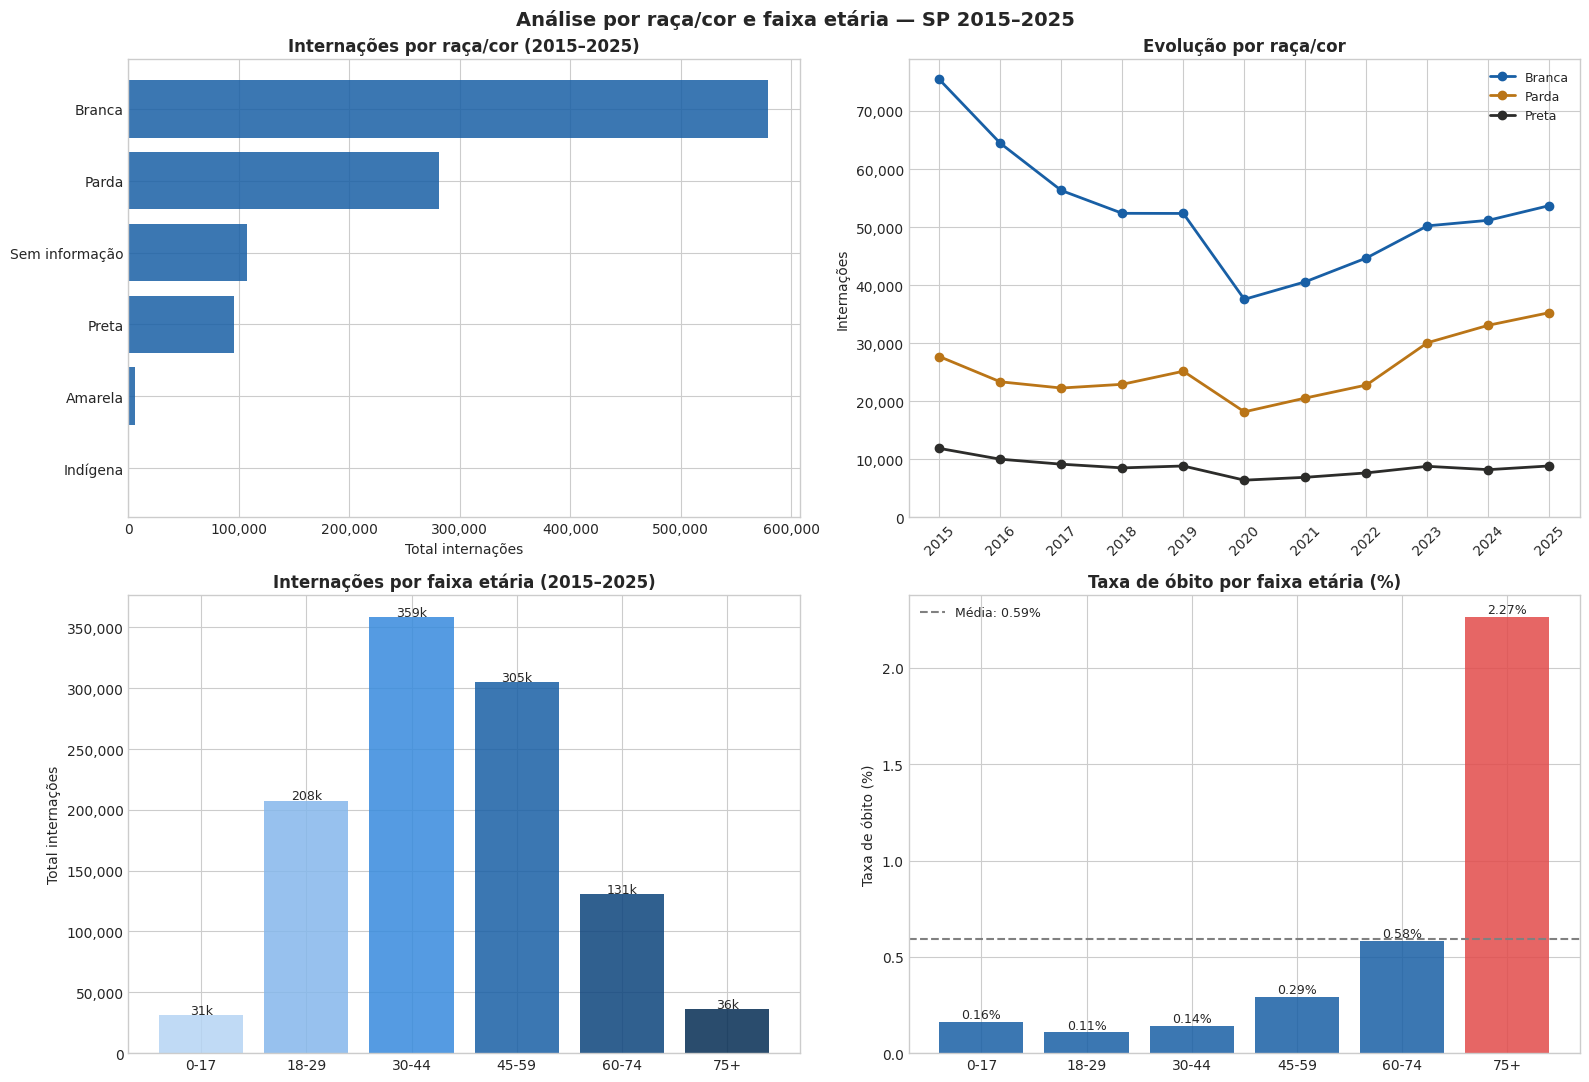

In [17]:
df_raca = query("""
    SELECT ano, raca_cor,
           COUNT(*) AS total_internacoes,
           SUM(obito) AS total_obitos
    FROM sus_pipeline.sih_internacoes_psiquiatria
    WHERE ano NOT IN ('2026')
    AND raca_cor IS NOT NULL
    AND raca_cor != ''
    GROUP BY ano, raca_cor
    ORDER BY ano, total_internacoes DESC
""")

df_idade = query("""
    SELECT * FROM (
        SELECT 
            ano,
            CASE 
                WHEN idade < 18 THEN '1_0-17'
                WHEN idade BETWEEN 18 AND 29 THEN '2_18-29'
                WHEN idade BETWEEN 30 AND 44 THEN '3_30-44'
                WHEN idade BETWEEN 45 AND 59 THEN '4_45-59'
                WHEN idade BETWEEN 60 AND 74 THEN '5_60-74'
                WHEN idade >= 75 THEN '6_75+'
            END AS faixa_etaria,
            COUNT(*) AS total_internacoes,
            SUM(obito) AS total_obitos,
            ROUND(SUM(obito) * 100.0 / COUNT(*), 2) AS taxa_obito
        FROM sus_pipeline.sih_internacoes_psiquiatria
        WHERE ano NOT IN ('2026')
        AND idade IS NOT NULL
        GROUP BY ano,
            CASE 
                WHEN idade < 18 THEN '1_0-17'
                WHEN idade BETWEEN 18 AND 29 THEN '2_18-29'
                WHEN idade BETWEEN 30 AND 44 THEN '3_30-44'
                WHEN idade BETWEEN 45 AND 59 THEN '4_45-59'
                WHEN idade BETWEEN 60 AND 74 THEN '5_60-74'
                WHEN idade >= 75 THEN '6_75+'
            END
    ) t
    WHERE faixa_etaria IS NOT NULL
    ORDER BY ano, faixa_etaria
""")

raca_map = {
    '01': 'Branca', '02': 'Preta', '03': 'Parda',
    '04': 'Amarela', '05': 'Indígena', '99': 'Sem informação'
}
faixa_map = {
    '1_0-17': '0-17', '2_18-29': '18-29', '3_30-44': '30-44',
    '4_45-59': '45-59', '5_60-74': '60-74', '6_75+': '75+'
}

df_raca['raca'] = df_raca['raca_cor'].map(raca_map)
df_idade['faixa'] = df_idade['faixa_etaria'].map(faixa_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# total por raça
raca_total = df_raca.groupby('raca').agg(
    total=('total_internacoes', 'sum')).reset_index()
raca_total = raca_total[raca_total['raca'].notna()]
raca_total = raca_total.sort_values('total', ascending=True)

ax = axes[0, 0]
ax.barh(raca_total['raca'], raca_total['total'].astype(float),
        color='#185FA5', alpha=0.85)
ax.set_title('Internações por raça/cor (2015–2025)', fontweight='bold')
ax.set_xlabel('Total internações')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# evolução por raça
ax = axes[0, 1]
cores_raca = {'Branca': '#185FA5', 'Parda': '#BA7517', 'Preta': '#2C2C2A'}
for raca, cor in cores_raca.items():
    dados = df_raca[df_raca['raca'] == raca].sort_values('ano')
    ax.plot(dados['ano'], dados['total_internacoes'].astype(float),
            marker='o', linewidth=2, color=cor, label=raca)
ax.set_title('Evolução por raça/cor', fontweight='bold')
ax.set_ylabel('Internações')
ax.legend(fontsize=9)
ax.set_xticks(df_raca['ano'].unique())
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# total por faixa etária
faixa_total = df_idade.groupby('faixa').agg(
    total=('total_internacoes', 'sum'),
    taxa_obito=('taxa_obito', 'mean')
).reset_index()
ordem = ['0-17', '18-29', '30-44', '45-59', '60-74', '75+']
faixa_total = faixa_total[faixa_total['faixa'].isin(ordem)]
faixa_total['faixa'] = pd.Categorical(faixa_total['faixa'], categories=ordem, ordered=True)
faixa_total = faixa_total.sort_values('faixa')

ax = axes[1, 0]
cores_f = ['#B5D4F4', '#85B7EB', '#378ADD', '#185FA5', '#0C447C', '#042C53']
bars = ax.bar(faixa_total['faixa'], faixa_total['total'].astype(float),
              color=cores_f, alpha=0.85)
for bar, v in zip(bars, faixa_total['total'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1000:.0f}k', ha='center', fontsize=9)
ax.set_title('Internações por faixa etária (2015–2025)', fontweight='bold')
ax.set_ylabel('Total internações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# taxa de óbito por faixa etária
ax = axes[1, 1]
cores_obito = ['#185FA5' if x < 1 else '#E24B4A'
               for x in faixa_total['taxa_obito'].astype(float)]
bars = ax.bar(faixa_total['faixa'], faixa_total['taxa_obito'].astype(float),
              color=cores_obito, alpha=0.85)
for bar, v in zip(bars, faixa_total['taxa_obito'].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.2f}%', ha='center', fontsize=9)
ax.set_title('Taxa de óbito por faixa etária (%)', fontweight='bold')
ax.set_ylabel('Taxa de óbito (%)')
ax.axhline(y=faixa_total['taxa_obito'].astype(float).mean(),
           color='gray', linestyle='--',
           label=f'Média: {faixa_total["taxa_obito"].astype(float).mean():.2f}%')
ax.legend(fontsize=9)

plt.suptitle('Análise por raça/cor e faixa etária — SP 2015–2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/09_raca_idade.png', dpi=150, bbox_inches='tight')
plt.show()